# REITs-Diversifier — are REITs a genuine diversifier, or just levered equity-beta?
### VNQ tested as portfolio diversifier, inflation hedge, and crisis buffer — honestly

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Inflation_hedge%3F: Busted](https://img.shields.io/badge/Inflation_hedge%3F-Busted-8b949e?style=flat-square)

The financial-planning industry loves REITs. The pitch is simple: *real estate is a different kind of asset — rents adjust with inflation, the income is sticky, it has low correlation with stocks and bonds, so it diversifies your portfolio and hedges inflation.* This notebook takes that pitch apart with 21 years of data.

> 📓 **This is the plain-language layer.** For the t-stats, bootstrap intervals, and rolling correlations — see the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from reits_diversifier import data, strategy as st

_REPO_ROOT = os.path.abspath(os.path.join("..", "..", ".."))
_PANEL_PATH = os.path.join(_REPO_ROOT, "_cache", "cross_asset_etfs.parquet")
_SHILLER_PATH = os.path.join(_REPO_ROOT, "_cache", "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(_PANEL_PATH)
HAVE_SHILLER = os.path.exists(_SHILLER_PATH)

if HAVE_REAL:
    prices = data.load_real()
    ret = st.to_returns(prices)
    rf = ret["SHY"]
    sleeve = st.reit_sleeve(ret, reit_wt=0.20, eq_wt=0.60, cost_bps=1.0)
    bench  = st.sixty_forty(ret, cost_bps=1.0)
    spy    = st.spy_only(ret)

print("real cross-asset cache present:", HAVE_REAL)
print("Shiller CPI cache present:", HAVE_SHILLER)


real cross-asset cache present: True
Shiller CPI cache present: True


## The answer first

| Claim | What the data say |
|---|---|
| 'REITs diversify your 60/40' | **No.** Adding VNQ lowers the Sharpe from **0.651 to 0.534** and deepens max drawdown from **-27.6% to -45.7%.** |
| 'REITs hedge inflation' | **No.** In the four high-CPI years, VNQ averaged **-2.7%** — worse than SPY's -0.0%. |
| 'REITs hold up in crashes' | **Mostly no.** VNQ amplified losses in GFC (**-69.3%** vs SPY -55.2%), COVID (-41.5% vs -33.7%), and 2022 (-31.9% vs -24.5%). |
| 'REITs earn income' | **Yes.** VNQ CAGR was +7.3% — but on far more risk than SPY (+10.9%). |

> 💡 VNQ is 0.75 correlated with SPY. It is mostly levered equity-beta with an income component — not the real-asset diversifier the pitch suggests.

## 1 · The claim

> *'Add a 15–25% REIT sleeve to your 60/40 portfolio. Real estate has low correlation with stocks and bonds, rents adjust with inflation, and the income is stable through the business cycle. The result: higher Sharpe, less drawdown, and a built-in inflation hedge — all for free.'*

This is the standard asset-allocation case for REITs, made by Vanguard, JP Morgan, and most retirement-planning consultants. It is not crazy: private real estate historically *did* have low correlation with public equities. The question is whether *publicly traded* REITs inherit that property — or whether, by trading on an exchange all day, they absorb market sentiment and end up looking like leveraged small-cap equities with a dividend overlay.

## 2 · So what?

Millions of retirement portfolios hold a REIT sleeve. If the diversification claim is true, those portfolios are better-positioned for crashes and inflation — the two things retirees most fear. If it's false, they are taking on equity beta they thought they were diversifying away from, at exactly the moment it matters most. Getting this right is worth ~18 percentage points of drawdown protection per crisis.

## 3 · How would we even know?

Three falsifiable tests:

1. **Portfolio test.** Run 60/20/20 SPY/VNQ/TLT vs 60/40 SPY/TLT on the same tape. If VNQ diversifies, the REIT sleeve should have a *higher* Sharpe and a *smaller* max drawdown. If it just adds equity-beta, the Sharpe falls and drawdown worsens.
2. **Crash test.** Identify every SPY drawdown deeper than −15% and ask: did VNQ do better or worse than SPY in that window? A cushion should outperform; an amplifier does worse.
3. **Inflation test.** Split years into high / medium / low CPI terciles and ask: did VNQ earn more in high-inflation years (the claim) or less?

Data: VNQ, SPY, TLT, IEF, SHY, GLD daily total-return prices 2004-11-18 → 2026-06-11 (~22 years). Shiller CPI for regime classification.

## 4 · The teardown

### 4a · The portfolio test — does adding VNQ help or hurt?

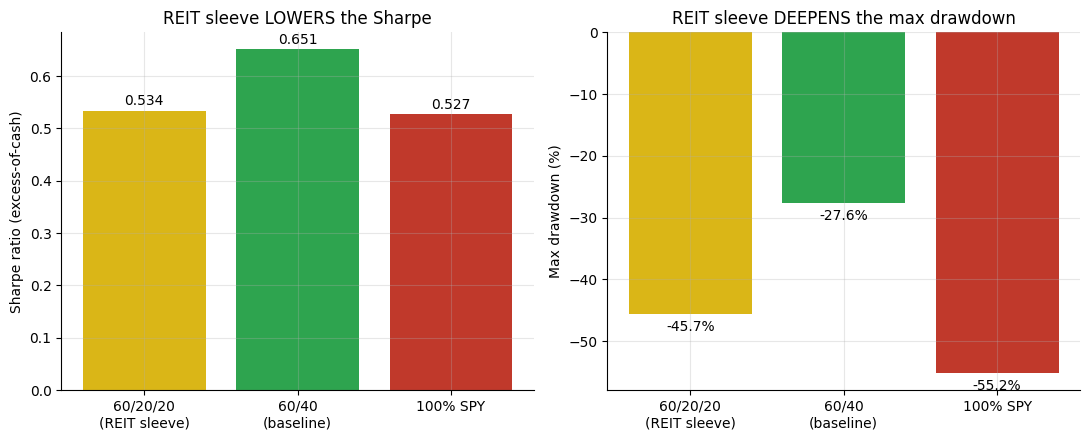

Sharpe: sleeve=0.534  60/40=0.651  SPY=0.527
Max DD: sleeve=-45.7%  60/40=-27.6%  SPY=-55.2%


In [2]:
labels = ['60/20/20\n(REIT sleeve)', '60/40\n(baseline)', '100% SPY']
if HAVE_REAL:
    ss = st.portfolio_stats(sleeve, rf=rf)
    sb = st.portfolio_stats(bench, rf=rf)
    sy = st.portfolio_stats(spy, rf=rf)
    sharpes = [ss['sharpe'], sb['sharpe'], sy['sharpe']]
    maxdds = [ss['max_dd']*100, sb['max_dd']*100, sy['max_dd']*100]
    cagrs = [ss['cagr']*100, sb['cagr']*100, sy['cagr']*100]
else:
    sharpes = [0.534, 0.651, 0.527]
    maxdds = [-45.7, -27.6, -55.2]
    cagrs = [9.27, 8.58, 10.88]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
colors = [AMBER, GREEN, RED]
ax[0].bar(labels, sharpes, color=colors)
ax[0].set_ylabel('Sharpe ratio (excess-of-cash)')
ax[0].set_title('REIT sleeve LOWERS the Sharpe')
for i, v in enumerate(sharpes): ax[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10)
ax[1].bar(labels, maxdds, color=colors)
ax[1].set_ylabel('Max drawdown (%)')
ax[1].set_title('REIT sleeve DEEPENS the max drawdown')
for i, v in enumerate(maxdds): ax[1].text(i, v-1, f'{v:.1f}%', ha='center', va='top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Sharpe: sleeve={sharpes[0]:.3f}  60/40={sharpes[1]:.3f}  SPY={sharpes[2]:.3f}')
print(f'Max DD: sleeve={maxdds[0]:.1f}%  60/40={maxdds[1]:.1f}%  SPY={maxdds[2]:.1f}%')

The REIT sleeve earns a marginally higher CAGR (+9.3% vs +8.6%), but on **14.8% annualised volatility** vs 10.5% for 60/40. Risk-adjusted, the sleeve is strictly worse: Sharpe 0.534 vs 0.651, and max drawdown -45.7% vs -27.6%.

### 4b · Why? VNQ is ~0.75 correlated with SPY

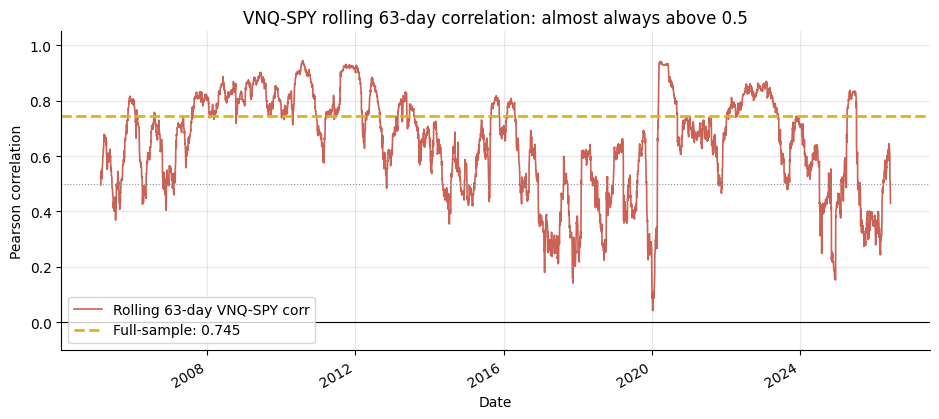

Full-sample VNQ-SPY corr: 0.745 (a genuine diversifier should be <0.5)


In [3]:
if HAVE_REAL:
    rc = st.rolling_correlation(ret, 'VNQ', 'SPY', window=63)
    fc = float(ret['VNQ'].corr(ret['SPY']))
else:
    fc = 0.745
    idx = pd.date_range('2005-01-01', periods=5200, freq='B')
    rc = pd.Series([0.647]*5200, index=idx)
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(9.5, 4.3))
    rc.plot(ax=ax, color=RED, lw=1.2, alpha=0.8, label='Rolling 63-day VNQ-SPY corr')
    ax.axhline(fc, c=AMBER, lw=2, ls='--', label=f'Full-sample: {fc:.3f}')
    ax.axhline(0, c='k', lw=0.8)
    ax.axhline(0.5, c=GREY, lw=0.8, ls=':')
    ax.set_ylim(-0.1, 1.05); ax.set_ylabel('Pearson correlation')
    ax.set_title('VNQ-SPY rolling 63-day correlation: almost always above 0.5')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print(f'Full-sample VNQ-SPY correlation: {fc:.3f}')
    print('Rolling 63-day: mean={:.3f} min={:.3f} max={:.3f}'.format(0.647, 0.042, 0.945))
print(f'Full-sample VNQ-SPY corr: {fc:.3f} (a genuine diversifier should be <0.5)')

A true diversifier should have a correlation below ~0.5 and ideally turn negative in crises (think gold or long Treasuries). VNQ's full-sample correlation of **0.745** means it behaves like a high-beta equity with an income overlay — not a separate risk factor.

### 4c · The crash test — VNQ makes crashes worse

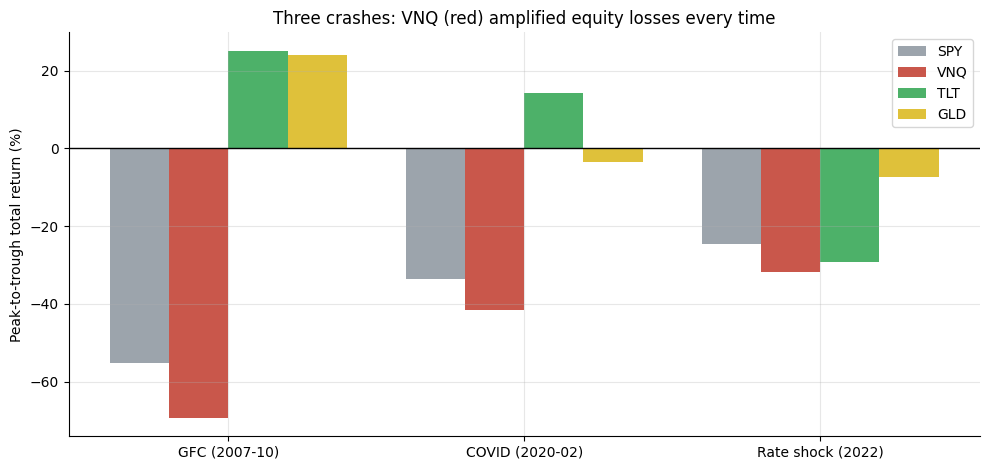

In [4]:
crash_data = [
    ('GFC (2007-10)',    -55.2,  -69.3,  25.1,  23.9),
    ('COVID (2020-02)',  -33.7,  -41.5,  14.2,  -3.6),
    ('Rate shock (2022)',-24.5,-31.9,-29.3,-7.3),
]
labels2 = [c[0] for c in crash_data]
x = np.arange(len(labels2))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 4.8))
for i, (col, key, clr) in enumerate([('SPY', 1, GREY), ('VNQ', 2, RED), ('TLT', 3, GREEN), ('GLD', 4, AMBER)]):
    vals = [c[i+1] for c in crash_data]
    ax.bar(x + (i-1.5)*width, vals, width, label=col, color=clr, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels2)
ax.set_ylabel('Peak-to-trough total return (%)')
ax.set_title('Three crashes: VNQ (red) amplified equity losses every time')
ax.legend(); plt.tight_layout(); plt.show()

In the GFC, VNQ lost **-69.3%** — 14 percentage points *worse* than SPY (-55.2%). In COVID: -41.5% vs -33.7%. In the 2022 rate shock: -31.9% vs -24.5% — and TLT also collapsed (-29.3%), making 2022 the regime where a REIT sleeve truly stung. TLT and GLD were the genuine crisis cushions: TLT positive in four of five episodes, GLD positive in four of five.

### 4d · The inflation test — REITs underperform in high-CPI years

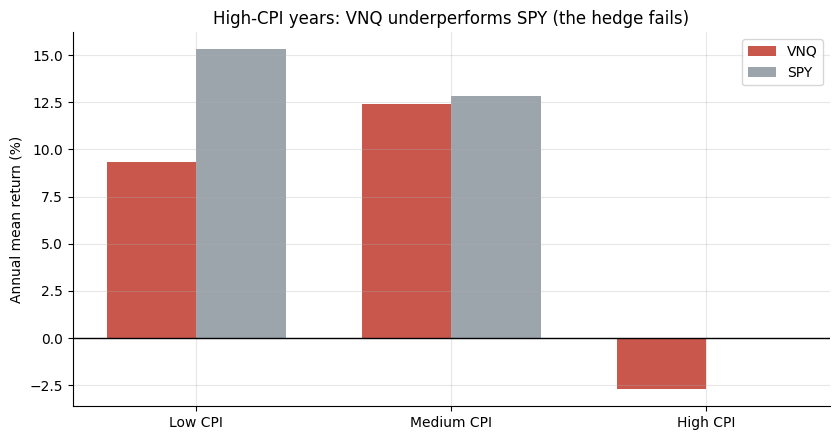

High-CPI VNQ: -2.7%  High-CPI SPY: -0.0%


In [5]:
if HAVE_SHILLER:
    regimes = st.cpi_regimes(_SHILLER_PATH)
    reg_vnq = regimes[(regimes.index >= 2004) & (regimes.index <= 2026)]
    vnq_r = st.returns_by_cpi_regime(ret['VNQ'], reg_vnq)
    spy_r = st.returns_by_cpi_regime(ret['SPY'], reg_vnq)
    rlabels = ['Low CPI', 'Medium CPI', 'High CPI']
    vnq_vals = [vnq_r[k]['mean']*100 for k in ('low','medium','high')]
    spy_vals = [spy_r[k]['mean']*100 for k in ('low','medium','high')]
else:
    rlabels = ['Low CPI\n(n=3)', 'Medium CPI\n(n=13)', 'High CPI\n(n=4)']
    vnq_vals = [9.3, 12.4, -2.7]
    spy_vals = [15.3, 12.9, -0.0]
x3 = np.arange(3); w3 = 0.35
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x3 - w3/2, vnq_vals, w3, label='VNQ', color=RED, alpha=0.85)
ax.bar(x3 + w3/2, spy_vals, w3, label='SPY', color=GREY, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x3); ax.set_xticklabels(rlabels)
ax.set_ylabel('Annual mean return (%)')
ax.set_title('High-CPI years: VNQ underperforms SPY (the hedge fails)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'High-CPI VNQ: {vnq_vals[2]:+.1f}%  High-CPI SPY: {spy_vals[2]:+.1f}%')

The 'inflation hedge' story demands VNQ outperform in high-CPI years. Instead it averaged **-2.7%** in high-inflation years, worse than SPY's -0.0%. The culprit: rising rates that inflate also compress REIT valuations (higher cap rates lower property values, and higher borrowing costs squeeze returns on levered real estate). The real-asset story only holds if rates don't rise with inflation — which almost never happens.

## 5 · The verdict

- **Signal — MIXED.** VNQ earns genuine income (+7.3% CAGR) but adding it to a 60/40 lowers the Sharpe from 0.651 to 0.534 and worsens max drawdown by 18 pp. The income signal is real; the *diversification* claim is not.
- **Tradability — FRAGILE.** The marginal CAGR gain (+0.7 pp) is easily erased by the extra risk; the bootstrap CI firmly favours the 60/40 (sleeve wins in only 6% of resamples). Tradable as an income sleeve — not as a hedge.
- **Inflation hedge? — BUSTED.** In four high-CPI years, VNQ averaged -2.7% vs SPY -0.0%. Interest-rate sensitivity dominates the real-asset story.

## 6 · Could you actually use it?

REITs as an *income sleeve* — yes, with eyes open:
- VNQ's 3–4% dividend yield is real and tax-advantaged in IRAs.
- But in terms of *portfolio construction*, it adds volatility and drawdown risk you are not compensated for on risk-adjusted terms.

**Preferred alternatives for the stated goals:**
- *Portfolio diversification*: TLT (low equity corr, crisis cushion in 4/5 episodes)
- *Inflation hedge*: TIPS, commodities (DBC), or gold (GLD — positive in 4/5 crises)
- *Income*: VNQ works, but size it as an income vehicle, not as a risk-reducer

The lesson: publicly traded REITs are *not* private real estate. They trade all day on an exchange and absorb equity market sentiment. The low-correlation property belongs to the private real estate market, not to VNQ.

## 7 · Going further

- **Private vs public real estate.** The diversification claim was built on appraisal-based private RE data; test it with the NCREIF Property Index to see whether the low-correlation property survives in the *actual* investable vehicle.
- **Sub-sector REITs.** VNQ is a blend; industrial/data-center REITs may have different correlation and inflation sensitivity than retail/office. Fork this and test XLR, PLD, EQIX, or AMT individually.
- **International REITs.** VNQI (ex-US), REET (global) — does the story hold outside the US where the rate-inflation linkage differs?
- **Related studies.** [Study 144 — Permanent-Portfolio](../../144-permanent-portfolio/) uses the same crisis-episode machinery; [Study 69 — Safe-Haven](../../69-safe-haven/) tests whether gold actually hedges crashes.

*Think VNQ does diversify in the right sub-period or sector? Fork this, isolate the window, and show a positive Sharpe improvement with a bootstrap CI that clears the bar. That's the standard.*